In [1]:
import tensorflow as tf
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.utils import class_weight
import numpy as np
import time
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import VGG16

In [2]:
 

# List all physical devices
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print("GPU is available!")
    print("GPU devices:", gpus)
else:
    print("GPU is NOT available. Using CPU.")


GPU is available!
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Before augmentation

Found 9959 images belonging to 4 classes.
Found 2487 images belonging to 4 classes.
Class Weights: {0: 0.8388645552560647, 1: 0.6129369768586903, 2: 2.259301270417423, 3: 1.3627531472359058}
Epoch 1/20
312/312 [==============================] - 146s 429ms/step - loss: 1.0877 - accuracy: 0.5266 - val_loss: 1.0226 - val_accuracy: 0.5380
Epoch 2/20
312/312 [==============================] - 43s 137ms/step - loss: 0.4145 - accuracy: 0.8571 - val_loss: 0.8387 - val_accuracy: 0.6393
Epoch 3/20
312/312 [==============================] - 43s 137ms/step - loss: 0.1964 - accuracy: 0.9434 - val_loss: 0.5889 - val_accuracy: 0.7668
Epoch 4/20
312/312 [==============================] - 43s 137ms/step - loss: 0.1109 - accuracy: 0.9719 - val_loss: 0.5330 - val_accuracy: 0.8150
Epoch 5/20
312/312 [==============================] - 43s 137ms/step - loss: 0.0684 - accuracy: 0.9831 - val_loss: 0.6056 - val_accuracy: 0.7636
Epoch 6/20
312/312 [==============================] - 43s 137ms/step - loss: 0.0438

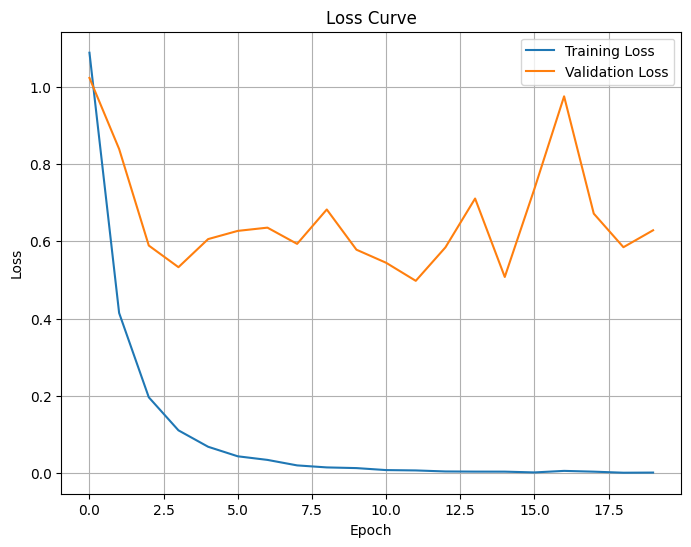

78/78 [==============================] - 8s 99ms/step


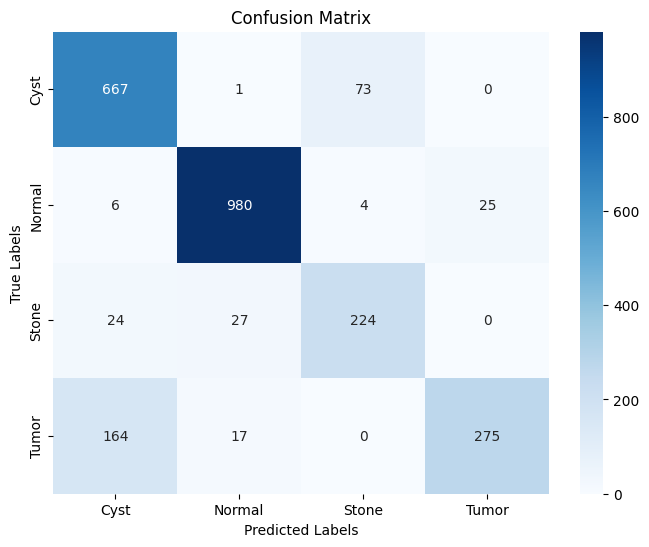

Training Time: 960.58 seconds
Testing Time: 8.02 seconds
Confusion Matrix:
 [[667   1  73   0]
 [  6 980   4  25]
 [ 24  27 224   0]
 [164  17   0 275]]
Classification Report:
               precision    recall  f1-score   support

        Cyst       0.77      0.90      0.83       741
      Normal       0.96      0.97      0.96      1015
       Stone       0.74      0.81      0.78       275
       Tumor       0.92      0.60      0.73       456

    accuracy                           0.86      2487
   macro avg       0.85      0.82      0.82      2487
weighted avg       0.87      0.86      0.86      2487

Overall Accuracy: 0.8629
Accuracy for class 'Cyst': 0.9001
Accuracy for class 'Normal': 0.9655
Accuracy for class 'Stone': 0.8145
Accuracy for class 'Tumor': 0.6031


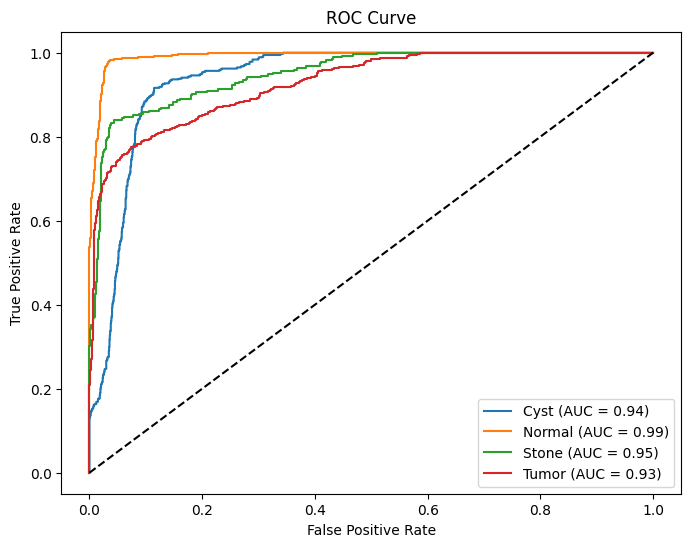

Overall Accuracy: 86.29%
Precision: 84.79%
Recall: 82.08%
F1-Score: 82.47%


In [3]:
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_CLASSES = 4
EPOCHS = 20
DATASET_PATH = "CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone"
 
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_generator = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_generator = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)
y_train = train_generator.classes

weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(weights))

print("Class Weights:", class_weights)
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)


base_model.trainable = True

for layer in base_model.layers[:-4]:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
outputs = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=outputs)


model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

start_train_time = time.time()

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    class_weight=class_weights

)

plt.figure(figsize=(8,6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()
plt.grid(True)
plt.show()

training_time = time.time() - start_train_time

start_test_time = time.time()

y_pred_prob = model.predict(val_generator)
y_pred_classes = np.argmax(y_pred_prob, axis=1)
y_true = val_generator.classes

testing_time = time.time() - start_test_time
class_names = list(val_generator.class_indices.keys())
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

class_report = classification_report(y_true, y_pred_classes, target_names=list(val_generator.class_indices.keys()))
accuracy = np.sum(y_pred_classes == y_true) / len(y_true)
print(f"Training Time: {training_time:.2f} seconds")
print(f"Testing Time: {testing_time:.2f} seconds")
print("Confusion Matrix:\n", cm)
print("Classification Report:\n", class_report)
print(f"Overall Accuracy: {accuracy:.4f}")
class_accuracy = cm.diagonal() / cm.sum(axis=1)
for i, class_name in enumerate(val_generator.class_indices.keys()):
    print(f"Accuracy for class '{class_name}': {class_accuracy[i]:.4f}")
y_true_onehot = to_categorical(y_true, num_classes=NUM_CLASSES)

plt.figure(figsize=(8, 6))
for i, class_name in enumerate(val_generator.class_indices.keys()):
    fpr, tpr, _ = roc_curve(y_true_onehot[:, i], y_pred_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{class_name} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()


accuracy = np.sum(y_pred_classes == y_true) / len(y_true)


precision = precision_score(y_true, y_pred_classes, average='macro')
recall = recall_score(y_true, y_pred_classes, average='macro')
f1 = f1_score(y_true, y_pred_classes, average='macro')

print(f"Overall Accuracy: {accuracy*100:.2f}%")
print(f"Precision: {precision*100:.2f}%")
print(f"Recall: {recall*100:.2f}%")
print(f"F1-Score: {f1*100:.2f}%")

From the loss curve, it can be seen that the training loss decreased while the validation loss fluctuated and increased, which indicates that the model is overfitting. It memorizes the training data. After using class weights, the model's performance for the tumor class is 0.61, while the normal class has 0.9655. Similarly, the recall and F1-score are also lowest for the tumor class. This means that class imbalance still exists even after applying class weights.

## After augmentation

Found 9959 images belonging to 4 classes.
Found 2487 images belonging to 4 classes.
Class Weights: {0: 0.8388645552560647, 1: 0.6129369768586903, 2: 2.259301270417423, 3: 1.3627531472359058}
Epoch 1/40
312/312 [==============================] - 158s 458ms/step - loss: 0.6287 - accuracy: 0.7405 - val_loss: 0.5239 - val_accuracy: 0.8086
Epoch 2/40
312/312 [==============================] - 98s 313ms/step - loss: 0.1400 - accuracy: 0.9514 - val_loss: 0.5583 - val_accuracy: 0.8323
Epoch 3/40
312/312 [==============================] - 112s 358ms/step - loss: 0.0723 - accuracy: 0.9767 - val_loss: 0.8214 - val_accuracy: 0.8347
Epoch 4/40
312/312 [==============================] - 186s 596ms/step - loss: 0.0416 - accuracy: 0.9858 - val_loss: 0.4911 - val_accuracy: 0.8436
Epoch 5/40
312/312 [==============================] - 110s 354ms/step - loss: 0.0361 - accuracy: 0.9891 - val_loss: 0.8525 - val_accuracy: 0.8239
Epoch 6/40
312/312 [==============================] - 99s 316ms/step - loss: 0.0

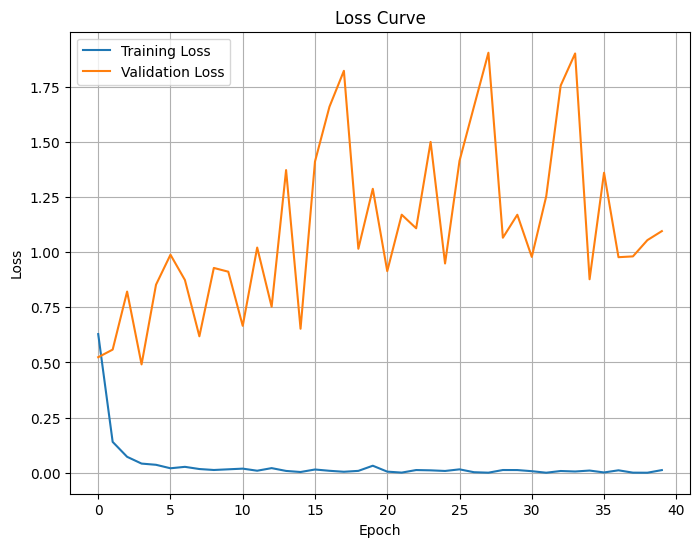

78/78 [==============================] - 8s 100ms/step


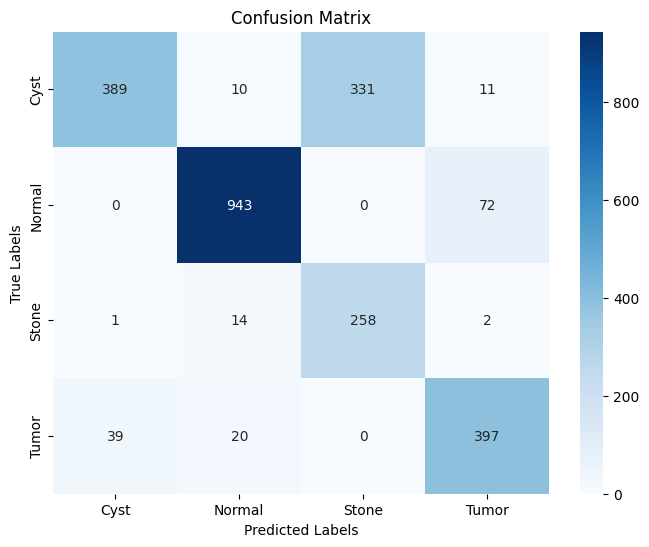

Training Time: 4063.04 seconds
Testing Time: 8.19 seconds
Confusion Matrix:
 [[389  10 331  11]
 [  0 943   0  72]
 [  1  14 258   2]
 [ 39  20   0 397]]
Classification Report:
               precision    recall  f1-score   support

        Cyst       0.91      0.52      0.66       741
      Normal       0.96      0.93      0.94      1015
       Stone       0.44      0.94      0.60       275
       Tumor       0.82      0.87      0.85       456

    accuracy                           0.80      2487
   macro avg       0.78      0.82      0.76      2487
weighted avg       0.86      0.80      0.80      2487

Overall Accuracy: 0.7990
Accuracy for class 'Cyst': 0.5250
Accuracy for class 'Normal': 0.9291
Accuracy for class 'Stone': 0.9382
Accuracy for class 'Tumor': 0.8706


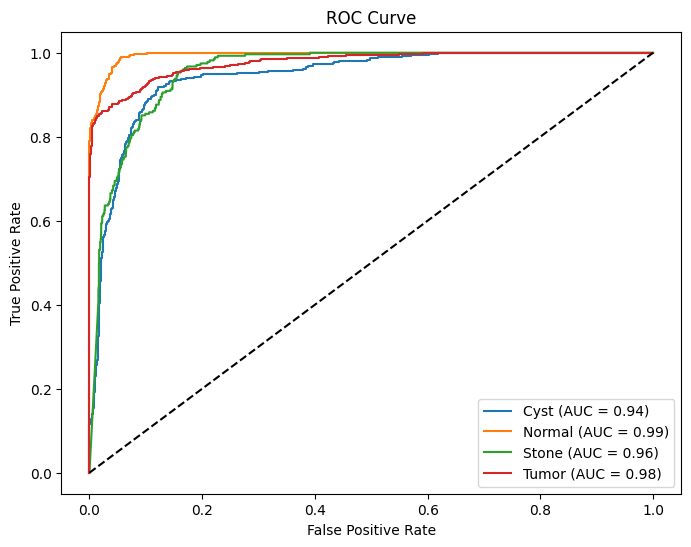

Overall Accuracy: 79.90%
Precision: 78.10%
Recall: 81.57%
F1-Score: 76.27%


In [3]:
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_CLASSES = 4
EPOCHS = 40
DATASET_PATH = "CT-KIDNEY-DATASET-Normal-Cyst-Tumor-Stone"
 
 
datagen = ImageDataGenerator(
    rescale=1./255,               
    rotation_range=20,             
    width_shift_range=0.2,        
    height_shift_range=0.2,        
    shear_range=0.15,             
    zoom_range=0.15,              
    horizontal_flip=True,          
    fill_mode='nearest',           
    validation_split=0.2           
)
train_generator = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

val_generator = val_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)
y_train = train_generator.classes

weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(weights))

print("Class Weights:", class_weights)
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)


base_model.trainable = True

for layer in base_model.layers[:-4]:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
outputs = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=outputs)


model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

start_train_time = time.time()

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    class_weight=class_weights

)

plt.figure(figsize=(8,6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()
plt.grid(True)
plt.show()

training_time = time.time() - start_train_time

start_test_time = time.time()

y_pred_prob = model.predict(val_generator)
y_pred_classes = np.argmax(y_pred_prob, axis=1)
y_true = val_generator.classes

testing_time = time.time() - start_test_time
class_names = list(val_generator.class_indices.keys())
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

class_report = classification_report(y_true, y_pred_classes, target_names=list(val_generator.class_indices.keys()))
accuracy = np.sum(y_pred_classes == y_true) / len(y_true)
print(f"Training Time: {training_time:.2f} seconds")
print(f"Testing Time: {testing_time:.2f} seconds")
print("Confusion Matrix:\n", cm)
print("Classification Report:\n", class_report)
print(f"Overall Accuracy: {accuracy:.4f}")
class_accuracy = cm.diagonal() / cm.sum(axis=1)
for i, class_name in enumerate(val_generator.class_indices.keys()):
    print(f"Accuracy for class '{class_name}': {class_accuracy[i]:.4f}")
y_true_onehot = to_categorical(y_true, num_classes=NUM_CLASSES)

plt.figure(figsize=(8, 6))
for i, class_name in enumerate(val_generator.class_indices.keys()):
    fpr, tpr, _ = roc_curve(y_true_onehot[:, i], y_pred_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{class_name} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()


accuracy = np.sum(y_pred_classes == y_true) / len(y_true)


precision = precision_score(y_true, y_pred_classes, average='macro')
recall = recall_score(y_true, y_pred_classes, average='macro')
f1 = f1_score(y_true, y_pred_classes, average='macro')

print(f"Overall Accuracy: {accuracy*100:.2f}%")
print(f"Precision: {precision*100:.2f}%")
print(f"Recall: {recall*100:.2f}%")
print(f"F1-Score: {f1*100:.2f}%")